In [1]:
# Cell 1: Setup and Imports
import sys
import os
import logging
from dynawo_notebooks.Scripts.core.visualizer import NetworkVisualizer
from dynawo_notebooks.Scripts.core.mo_topology import MoTopologyToolkit
from dynawo_notebooks.Scripts.core.powerflow import PowerFlowRunner
from IPython.display import SVG, display, HTML

# Configure notebook logging to show INFO messages
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S"
)

# Add Scripts directory to path
current_dir = os.getcwd()
scripts_path = os.path.join(current_dir, "../Scripts")
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

# Configurations
SOURCE_DIR = "../Models"
MODEL_NAME = "Dynawo.Examples.IEEE57.TestCases.IEEE57NoEvent"
DYNAWO_PKG = "/home/guiu/Projects/Dynawo/nightly/dynawo/ddb/Dynawo/package.mo"
LOCAL_FILES = ["IEEE57NoEvent.mo", "IEEE57Base.mo", "IEEE57BaseHvdcPs.mo"]
JSON_MODELS_PATH = "Models/parsed_models_data.json"

print("Toolkit loaded.")

Toolkit loaded.


In [2]:
# Instantiate the Toolkit (Facade)
toolkit = MoTopologyToolkit(SOURCE_DIR, MODEL_NAME, DYNAWO_PKG, LOCAL_FILES)

# Execute Parsing Pipeline
parsed_data = toolkit.parse_electrical_data()
# Export for verification
toolkit.export_to_standard_json(parsed_data, "grid_export_IEEE57.json")

# Import for verification
# parsed_data = toolkit.import_from_standard_json("grid_export_IEEE57.json")

print(f"Parsing successful. Found {len(parsed_data['generators'])} generators.")

17:36:32 [INFO] ============================================================
17:36:32 [INFO] Initializing MoTopologyToolkit for model: Dynawo.Examples.IEEE57.TestCases.IEEE57NoEvent
17:36:32 [INFO] ============================================================
17:36:32 [INFO] Connecting to OpenModelica Compiler (OMC)...
17:36:32 [INFO] Local OMC Server is up and running at ZMQ port tcp://127.0.0.1:37443 pid=26915
17:36:32 [INFO] OMC Session established successfully.
17:36:32 [INFO] Loading Standard Modelica Libraries...
17:36:33 [INFO] Loading Dynawo Package from: /home/guiu/Projects/Dynawo/nightly/dynawo/ddb/Dynawo/package.mo
17:36:34 [INFO] Loading 3 local files from /home/guiu/Projects/dynawo-notebooks/src/dynawo_notebooks/Models...
17:36:34 [INFO] Checking model: Dynawo.Examples.IEEE57.TestCases.IEEE57NoEvent
17:36:35 [WARNING] [OMC log for 'sendExpression(checkModel(Dynawo.Examples.IEEE57.TestCases.IEEE57NoEvent), True)']: [translation:warning:150] Connector switchOffSignal3 is not 

Parsing successful. Found 7 generators.


In [3]:
# Cell 3: Build PowSybl Network

network = toolkit.build_powsybl_network(parsed_data)

print("Network constructed successfully.")
print(f"- Buses: {len(network.get_buses())}")
print(f"- Lines: {len(network.get_lines())}")
print(f"- Generators: {len(network.get_generators())}")
print(f"- Loads: {len(network.get_loads())}")
print(f"- Shunts: {len(network.get_shunt_compensators())}")
print(f"- Transformers: {len(network.get_2_windings_transformers())}")

17:36:38 [INFO] >>> STEP 2: CONVERTING TO POWSYBL
17:36:39 [INFO] Initializing PyPowSybl Network construction...


Network constructed successfully.
- Buses: 57
- Lines: 63
- Generators: 7
- Loads: 42
- Shunts: 3
- Transformers: 17


17:36:39 [INFO] Generating full system visualization diagrams...


Rendering Network Diagrams...


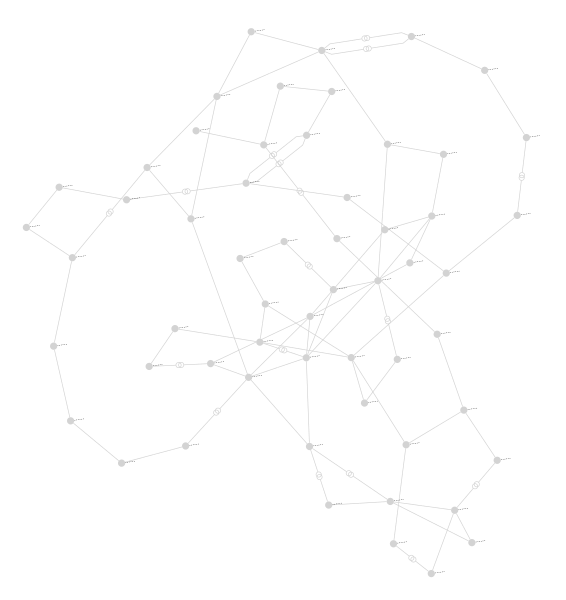

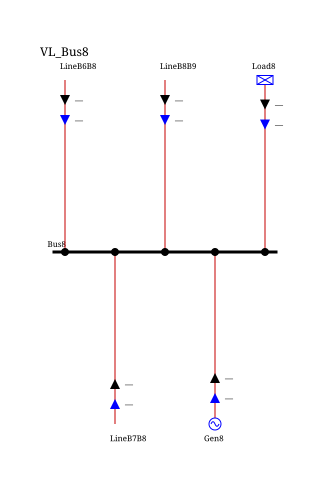

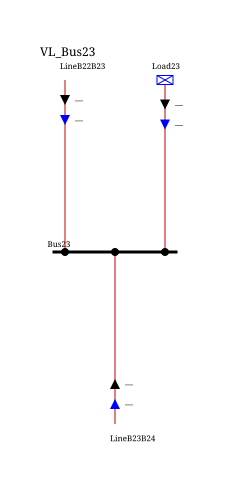

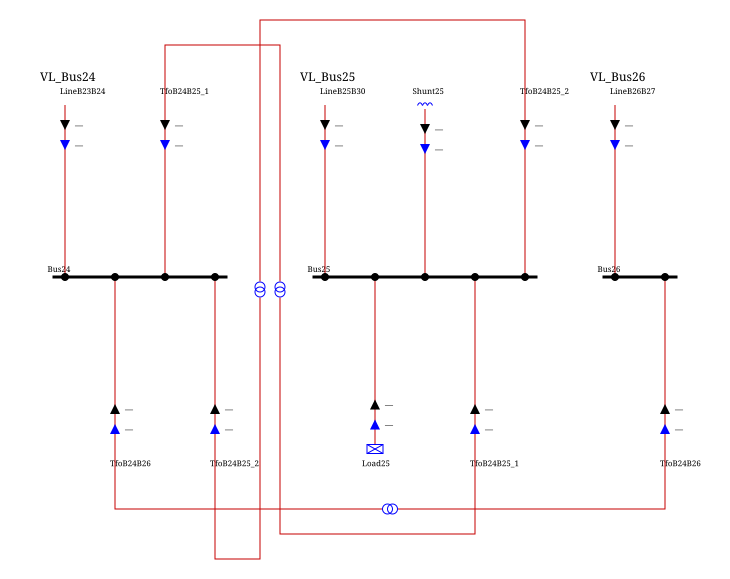

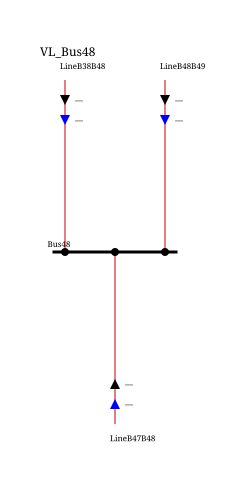

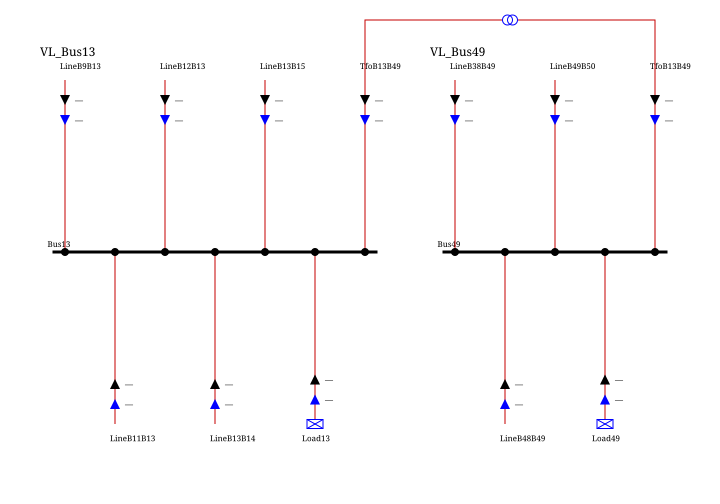

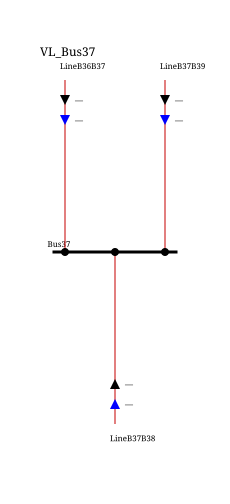

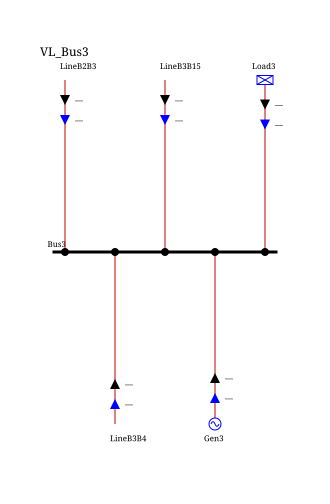

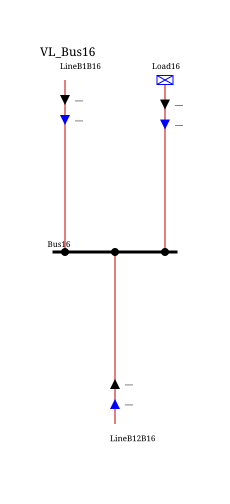

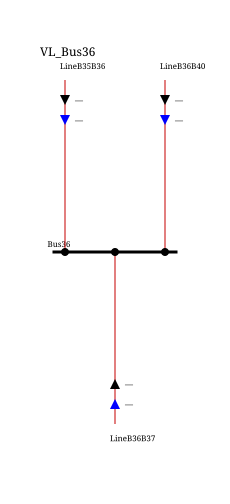

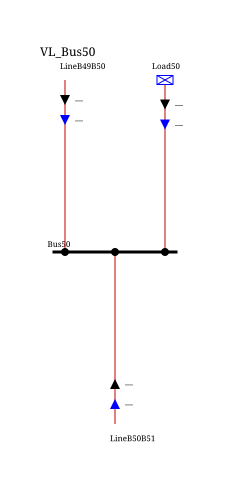

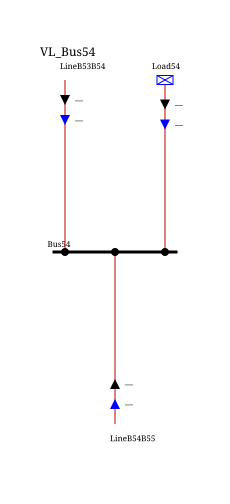

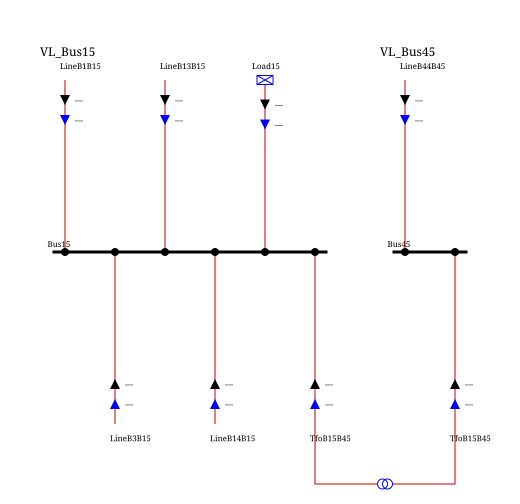

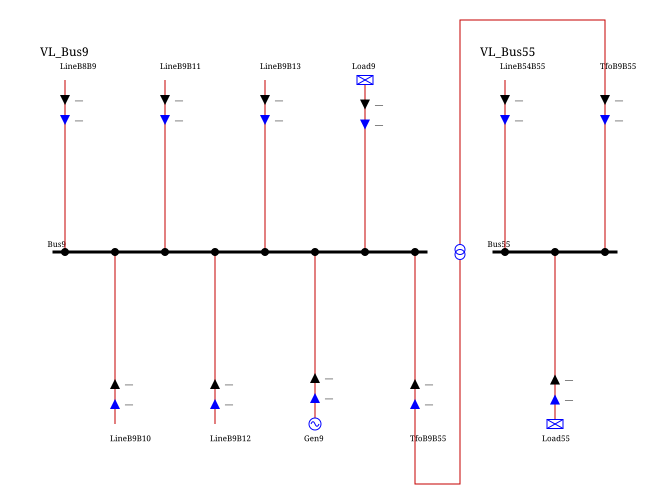

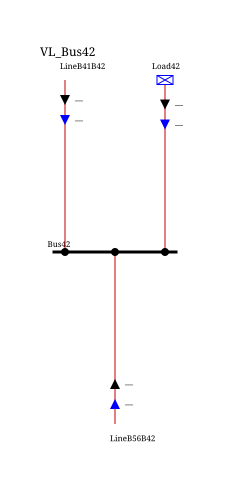

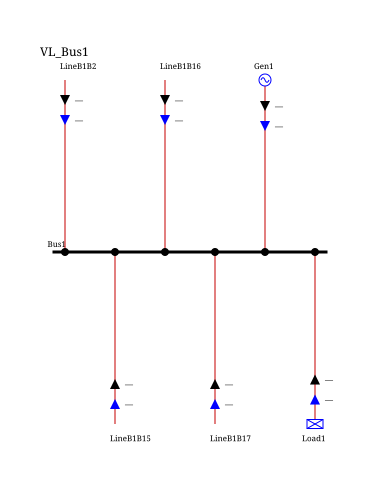

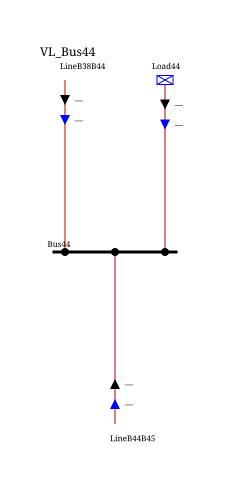

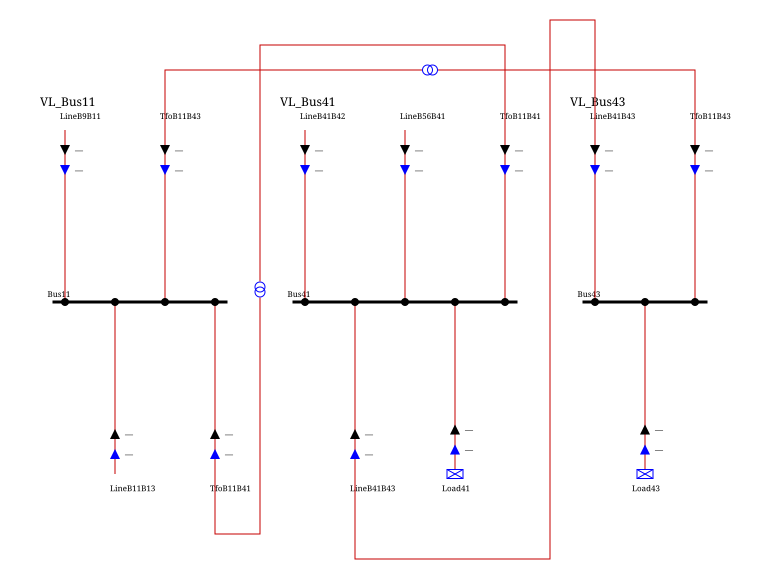

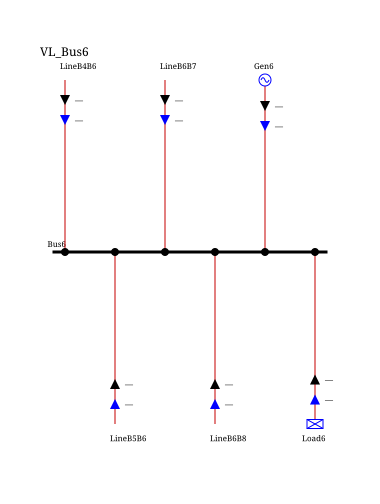

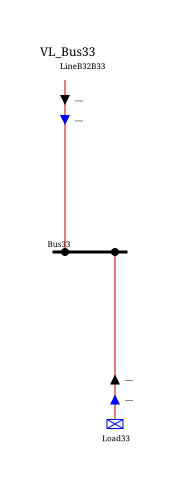

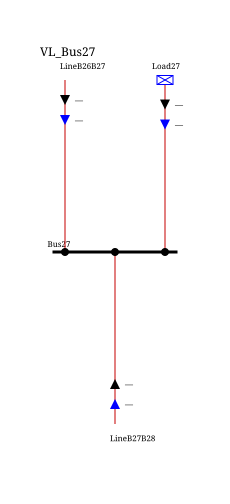

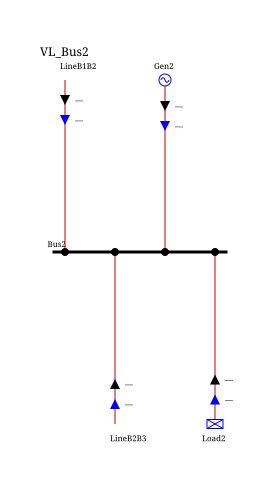

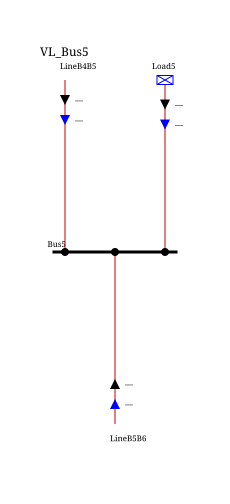

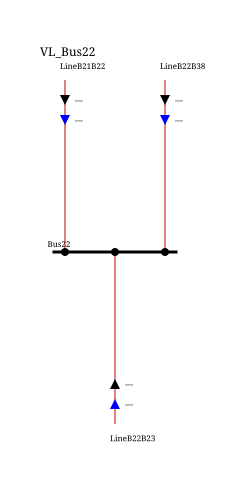

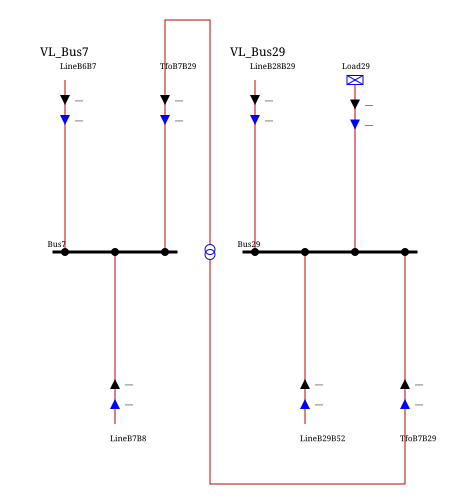

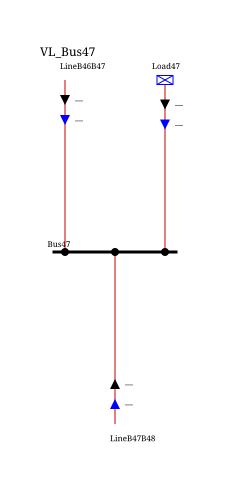

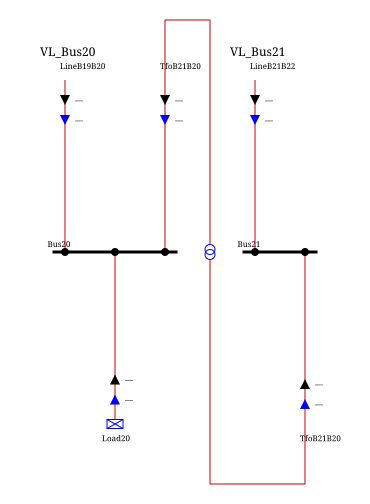

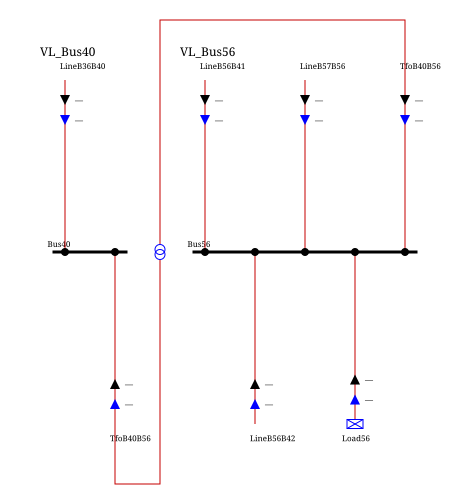

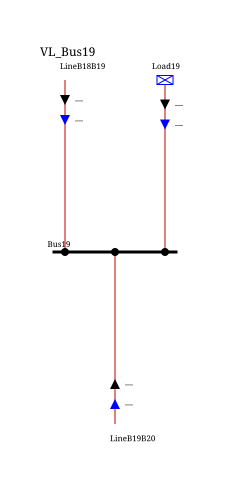

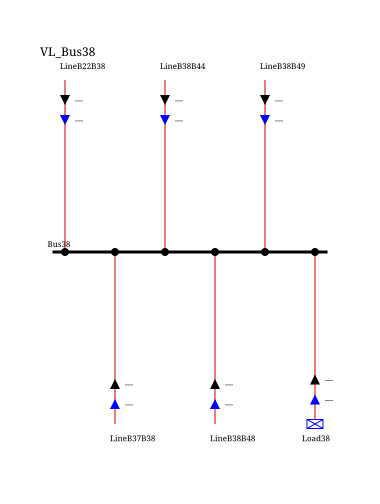

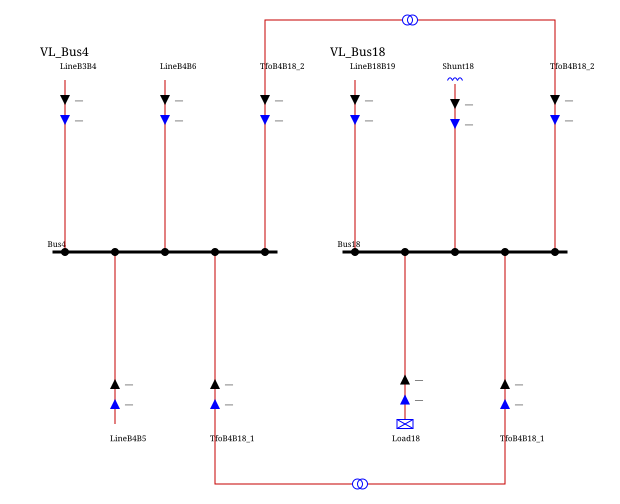

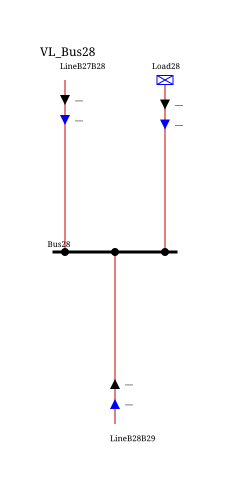

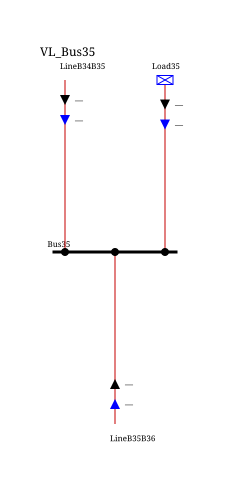

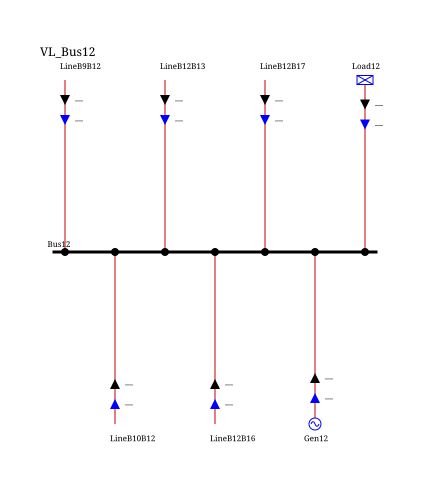

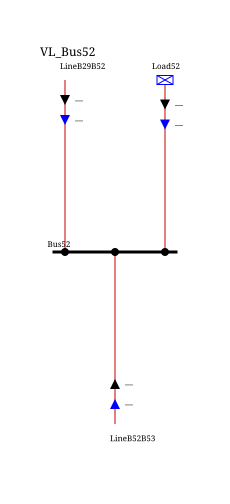

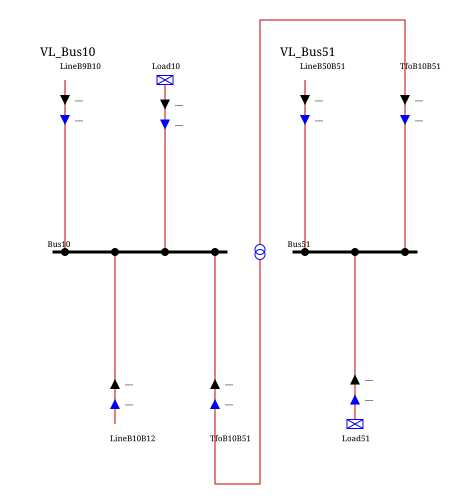

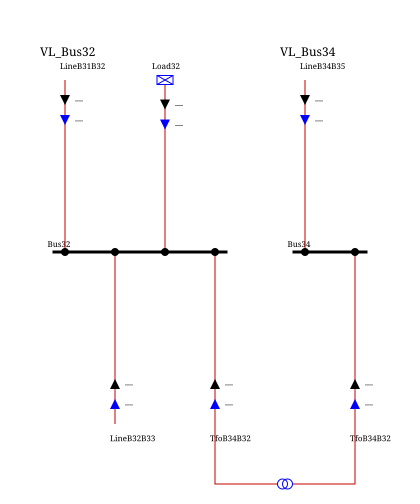

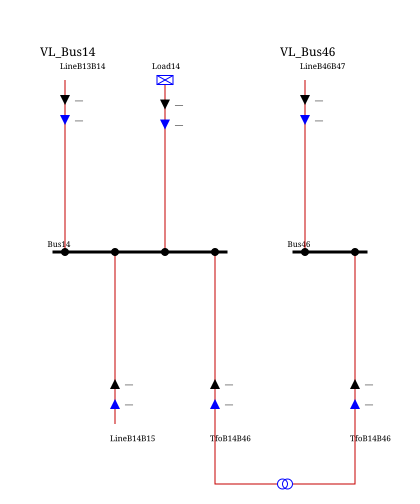

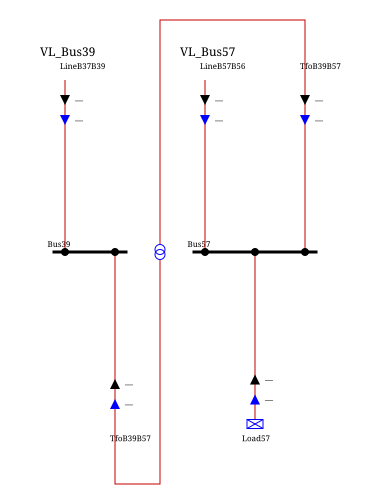

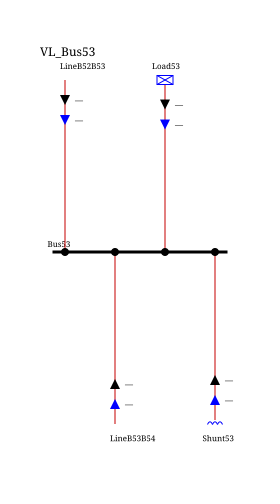

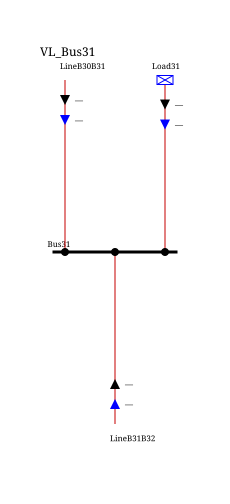

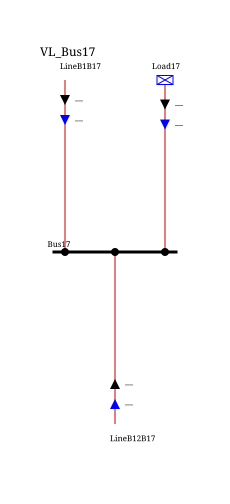

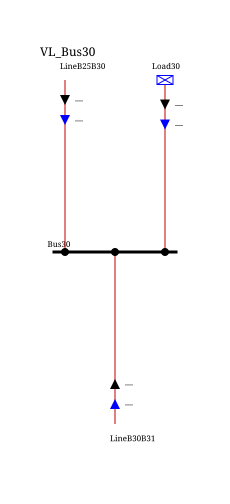

In [4]:
# Cell 4: Network Visualization

print("Rendering Network Diagrams...")
diagrams = NetworkVisualizer.generate_full_system_diagrams(network)

# 1. Display Macro View
if "network_area" in diagrams:
    display(HTML("<h3>Macro View: Network Area (Lines & Substations)</h3>"))
    display(SVG(str(diagrams["network_area"])))

# 2. Display Micro Views (Generators, Loads, etc.)
display(HTML("<h3>Micro View: Substations Details (Generators visible)</h3>"))
for name, svg in diagrams.items():
    if name != "network_area":
        display(HTML(f"<b>Substation: {name}</b>"))
        display(SVG(str(svg)))

In [5]:
# Cell 5: AC Load Flow Execution and Results
from dynawo_notebooks.Scripts.core.powerflow import PowerFlowRunner
from IPython.display import display

print("Starting AC Load Flow analysis...")

# 1. Execute the Load Flow
is_converged = PowerFlowRunner.run_ac_loadflow(network)

if is_converged:
    print("\nSUCCESS: Load flow CONVERGED!")

    # 2. Extract Bus Data (Voltages and Angles)
    print("\n--- BUS RESULTS (Voltages & Angles) ---")
    try:
        buses_df = network.get_buses()
        # In newer versions, we focus on voltage magnitude and angle
        # P and Q injections are viewed at the equipment level or via 'v_mag'/'v_angle'
        columns_buses = ["v_mag", "v_angle"]
        display(buses_df[columns_buses])
    except Exception as e:
        print(f"Could not retrieve Bus results: {e}")

    # 3. Extract Generator Data (To see P and Q output)
    print("\n--- GENERATOR RESULTS (Active & Reactive Power) ---")
    try:
        gens_df = network.get_generators()
        # 'p' and 'q' are the calculated values after loadflow
        columns_gens = ["bus_id", "p", "q", "target_p", "target_v"]
        display(gens_df[columns_gens])
    except Exception as e:
        print(f"Could not retrieve Generator results: {e}")

    # 4. Extract Line Data
    print("\n--- LINE RESULTS (Power Flows & Currents) ---")
    try:
        lines_df = network.get_lines()
        columns_lines = ["bus1_id", "bus2_id", "p1", "q1", "p2", "q2", "i1", "i2"]
        display(lines_df[columns_lines])
    except Exception as e:
        print(f"Could not retrieve Line results: {e}")

else:
    print("\nFAILED: Load flow did NOT converge.")

# Save network
toolkit.save_powsybl_network(network, export_path="grid_export_IEEE57")

17:36:39 [INFO] Starting AC Load Flow calculation (OpenLoadFlow)...
17:36:39 [INFO] Auto-detected Slack Bus: VL_Bus1_0 (from generator Gen1)
17:36:39 [WARNING] WARNING: Load flow DID NOT CONVERGE. Status: ComponentStatus.MAX_ITERATION_REACHED
17:36:39 [WARNING] Status Details: Reached Newton-Raphson max iterations limit
17:36:39 [WARNING] Iterations performed: 16
17:36:39 [WARNING] Reference Bus (Slack) used: VL_Bus1_0
17:36:39 [INFO] >>> SAVING PYPOWSYBL NETWORK TO: grid_export_IEEE57
17:36:39 [INFO] Network saved successfully. Ready for manual inspection.


Starting AC Load Flow analysis...

FAILED: Load flow did NOT converge.


In [6]:
# Cell 6: Cross-Validation with OpenModelica (OMPython)
from dynawo_notebooks.Scripts.core.comparison import LoadFlowComparator

print("Running Ground Truth Validation...")
print("1. Compiling and simulating the Modelica model via OMC...")

# This will trigger the OMC compiler to solve the non-linear system (t=0.0)
# It might take ~10-30 seconds depending on the Nordic 32 complexity.
comparison_df = LoadFlowComparator.compare_voltages(
    network=network, connector=toolkit.connector, model_name=MODEL_NAME, parsed_data=parsed_data
)

if not comparison_df.empty:
    print("\nSUCCESS: Validation completed! Showing top discrepancies (sorted by Δ V):")

    # Highlight cells with an error larger than 0.001 pu (0.1%)
    def highlight_errors(val):
        color = "orange" if isinstance(val, (int, float)) and val > 0.001 else "black"
        return f"color: {color}"

    # Apply style to error columns (CAMBIADO a .map)
    styled_df = comparison_df.style.map(
        highlight_errors, subset=["Δ V (pu)", "Δ Theta (deg)"]
    ).format("{:.4f}", na_rep="N/A")

    display(styled_df)

    # Print summary metrics
    mean_v_err = comparison_df["Δ V (pu)"].mean()
    mean_th_err = comparison_df["Δ Theta (deg)"].mean()
    print(f"\n--- Benchmark Summary ---")
    print(f"Average Voltage Mismatch: {mean_v_err:.6f} pu")
    print(f"Average Angle Mismatch:   {mean_th_err:.6f} deg")
else:
    print("Validation failed. Could not retrieve comparison data.")

17:36:39 [INFO] Initiating cross-platform Load Flow comparison...
17:36:39 [INFO] Starting OMC simulation for 'Dynawo.Examples.IEEE57.TestCases.IEEE57NoEvent' (stopTime=0.0). This may take a moment...


Running Ground Truth Validation...
1. Compiling and simulating the Modelica model via OMC...


17:36:49 [WARNING] [OMC log for 'sendExpression(simulate(Dynawo.Examples.IEEE57.TestCases.IEEE57NoEvent, stopTime=0.0), True)']: [translation:warning:150] Connector switchOffSignal3 is not balanced: The number of potential variables (1) is not equal to the number of flow variables (0).
17:36:49 [WARNING] [OMC log for 'sendExpression(simulate(Dynawo.Examples.IEEE57.TestCases.IEEE57NoEvent, stopTime=0.0), True)']: [translation:warning:150] Connector QGenPu is not balanced: The number of potential variables (1) is not equal to the number of flow variables (0).
17:36:49 [WARNING] [OMC log for 'sendExpression(simulate(Dynawo.Examples.IEEE57.TestCases.IEEE57NoEvent, stopTime=0.0), True)']: [translation:warning:150] Connector UPu is not balanced: The number of potential variables (1) is not equal to the number of flow variables (0).
17:36:49 [WARNING] [OMC log for 'sendExpression(simulate(Dynawo.Examples.IEEE57.TestCases.IEEE57NoEvent, stopTime=0.0), True)']: [translation:warning:150] Connect


SUCCESS: Validation completed! Showing top discrepancies (sorted by Δ V):


KeyError: "['Δ Theta (deg)'] not in index"

KeyError: 'Δ Theta (deg)'

In [ ]:
# Cell 7: Dynamic Model Linking
from dynawo_notebooks.Scripts.core.model_linker import link_models

# Path to the JSON file generated by the XML parser utility
# This file contains the registry of available dynamic models
JSON_MODELS_PATH = "../Models/parsed_models_data.json"

print("Starting dynamic model linking process...")

try:
    # This function associates static elements (IIDM) with dynamic models (Modelica)
    # mapping is an object containing the ModelMapping result
    mapping = link_models(network, JSON_MODELS_PATH)

    if mapping is not None:
        print("SUCCESS: Dynamic models have been linked to the network elements.")
    else:
        print("WARNING: Model linking returned None. Check if the JSON path is correct.")

except Exception as e:
    print(f"CRITICAL ERROR during model linking: {e}")